# Fuhrlaender Python Pipeline

Python equivalent of the R + MATLAB code.

**Flow:** Load turbines -> Resample 5-min to 1h -> Feature selection (two-phase RF) -> Train ELM on WT80-83 -> Apply to WT84 -> Anomaly detection plot

Only change the `CONFIG` cell.

In [1]:
import bz2, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# -- CHANGE THESE -----------------------------------------------------------
DATASET_PATH = r"C:\Eminds pros\E-minds projects\fuhrlander\FUHRLANDER GITHUB REPO\dataset"
TRAIN_IDS     = [80, 81, 82, 83]       # turbines used for training
TEST_ID       = 84            # turbine to run anomaly detection on

RESAMPLE_FREQ = "1h"                   # resample raw 5-min data to this
RF_TREES      = 100                    # random forest trees per phase
MAX_VARS      = 10                     # number of X_vars to select
ELM_K_RANGE   = [25, 50, 75, 100, 125, 150]  # hidden-neuron counts to try

FAILURE_DATE  = None          # WT84 gearbox failure (approx)
ANOMALY_WINDOW = 24 * 7               # rolling window in hours (1 week)

SAVE_FREQ     = "5min"                # SAVED feature CSVs = RAW 5-min (for causal/window pipeline)
OUTPUT_DIR    = r"C:\Eminds pros\E-minds projects\fuhrlander\FUHRLANDER GITHUB REPO\output"
# ---------------------------------------------------------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                      'axes.grid': True, 'grid.alpha': 0.3})
print('Config OK')


Config OK


## 1 -- Helper Functions

`filtered_3sdv_mean` mirrors MATLAB's `filtered_3sdv_mean`: within each 1-hour block, discard readings outside mean +/- 3 sigma then average the rest.

In [2]:
def filtered_3sdv_resample(df_sensors, freq):
    """Per-column vectorised filtered_3sdv_mean resampling."""
    results = {}
    hour_idx = df_sensors.index.floor(freq)
    for col in df_sensors.columns:
        s = pd.Series(df_sensors[col].values.astype(float), index=df_sensors.index)
        mu    = s.groupby(hour_idx).transform('mean')
        sigma = s.groupby(hour_idx).transform('std').fillna(0)
        good  = sigma.replace(0, np.inf)
        s_filtered = s.where((s - mu).abs() <= 3 * good)
        results[col] = s_filtered.resample(freq).mean()
    return pd.DataFrame(results)


def build_alarm_active(ts_index, alarms_dict, alarm_ids):
    """Binary series: 1 where any transmission alarm was active."""
    alarm_active = np.zeros(len(ts_index), dtype=np.int8)
    aids   = alarms_dict['alarm_id']
    starts = alarms_dict['date_time_ini']
    ends   = alarms_dict['date_time_end']
    for i in range(len(aids)):
        if aids[i] in alarm_ids:
            t0 = pd.Timestamp(starts[i])
            t1 = pd.Timestamp(ends[i])
            if t0 > t1: t0, t1 = t1, t0   # fix swapped timestamps in raw data
            lo = ts_index.searchsorted(t0)
            hi = ts_index.searchsorted(t1, side='right')
            alarm_active[lo:hi] = 1
    return pd.Series(alarm_active, index=ts_index)


def load_turbine(turbine_id, transmission_ids, dataset_path, resample_freq):
    """Load one turbine JSON.bz2, add alarm_active, resample."""
    plant = json.loads(open(f'{dataset_path}/wind_plant_data.json').read())
    turbs = plant['turbines']
    idx   = turbs['turbine_id'].index(turbine_id)
    fname = turbs['compressed_filename'][idx]
    with open(f'{dataset_path}/{fname}', 'rb') as f:
        raw = json.loads(bz2.decompress(f.read()).decode('utf-8'))
    ad  = raw['analog_data']
    ts  = pd.to_datetime(ad['date_time'])
    sensors = {k: v for k, v in ad.items() if k not in ('turbine_id', 'date_time')}
    df  = pd.DataFrame(sensors, index=ts)
    df.index.name = 'date_time'
    alarm = build_alarm_active(ts, raw['alarms'], transmission_ids)
    alarm.index = ts
    print(f'  WT{turbine_id}: {len(ts):,} raw rows -> resampling...', end=' ', flush=True)
    df_h = filtered_3sdv_resample(df, resample_freq)
    df_h['alarm_active'] = alarm.resample(resample_freq).max().values
    print(f'{len(df_h):,} hourly rows  |  alarm hours: {int(df_h["alarm_active"].sum())}')
    return df_h


print('Helpers defined OK')


Helpers defined OK


## 2 -- Load All Turbines

Loads WT80-83 (training) and WT84 (anomaly test). Each takes ~30-60 s to resample.

In [3]:
plant = json.loads(open(f'{DATASET_PATH}/wind_plant_data.json').read())
ad = plant['alarm_dictionary']
transmission_ids = set(
    ad['alarm_id'][i] for i in range(len(ad['alarm_id']))
    if ad['alarm_system'][i] == 'Transmission'
)
print(f'Transmission alarm types: {len(transmission_ids)}')

print('\nLoading turbines...')
turbines = {}
for tid in TRAIN_IDS + [TEST_ID]:
    turbines[tid] = load_turbine(tid, transmission_ids, DATASET_PATH, RESAMPLE_FREQ)

print('\nLoad complete.')


Transmission alarm types: 64

Loading turbines...
  WT80: 215,460 raw rows -> resampling... 25,734 hourly rows  |  alarm hours: 10455
  WT81: 215,613 raw rows -> resampling... 25,734 hourly rows  |  alarm hours: 10970
  WT82: 213,283 raw rows -> resampling... 25,734 hourly rows  |  alarm hours: 8412
  WT83: 213,472 raw rows -> resampling... 25,734 hourly rows  |  alarm hours: 7594
  WT84: 210,698 raw rows -> resampling... 25,734 hourly rows  |  alarm hours: 7844

Load complete.


## 3 -- Feature Selection (Two-Phase RF)

Mirrors `feature_selection.m`:

- **Phase 1**: RF(all sensors -> alarm_active) -- finds the sensor most correlated with gearbox faults -> `Y_VAR`
- **Phase 2**: RF(all other sensors -> Y_VAR) -- finds the top `MAX_VARS` predictors -> `X_VARS`

Runs on the FIRST 50% of the combined WT80-83 data (training split).

Combined training set: 51,468 rows x 313 columns
Alarm-active hours: 7878 / 51468
Rows without NaN: 41,640

Phase 1: RF(all sensors -> alarm_active)...
  Y_VAR (best response): "wrot_avg_A_ValBl1"
  Top 5 by alarm importance:
wrot_avg_A_ValBl1       0.1569
wrot_avg_A_ValBl2       0.1159
wrot_avg_V_ValBl1       0.0665
wrot_avg_V_ValBl2       0.0273
wtrm_avg_Gbx_OilPres    0.0219


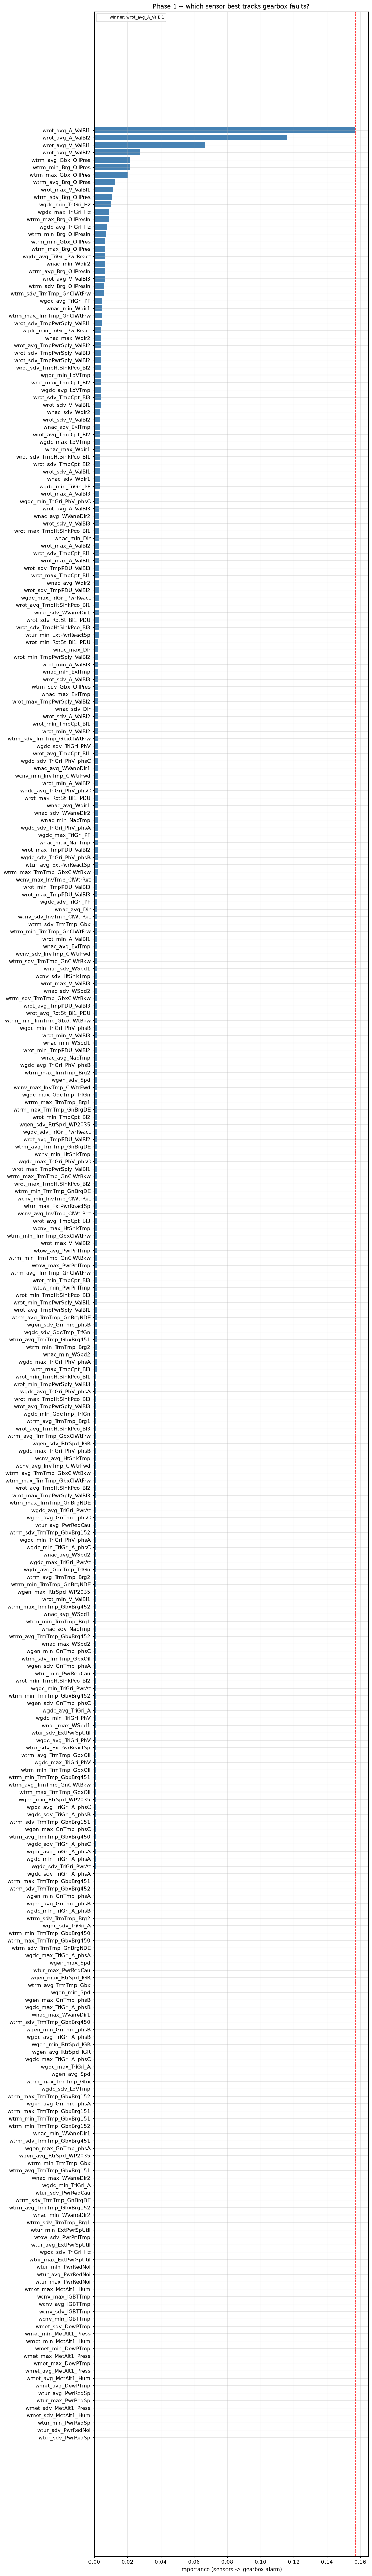


Phase 2: RF(remaining sensors -> wrot_avg_A_ValBl1)...
  Selected X_VARS (top 10):
wrot_avg_V_ValBl2             0.7089
wrot_avg_A_ValBl2             0.1612
wrot_avg_A_ValBl3             0.0422
wrot_avg_V_ValBl1             0.0173
wrot_min_TmpPwrSply_ValBl1    0.0156
wrot_min_A_ValBl1             0.0098
wrot_max_A_ValBl2             0.0053
wrot_sdv_TmpHtSinkPco_Bl1     0.0047
wrot_max_V_ValBl1             0.0035
wrot_max_TmpPwrSply_ValBl1    0.0028


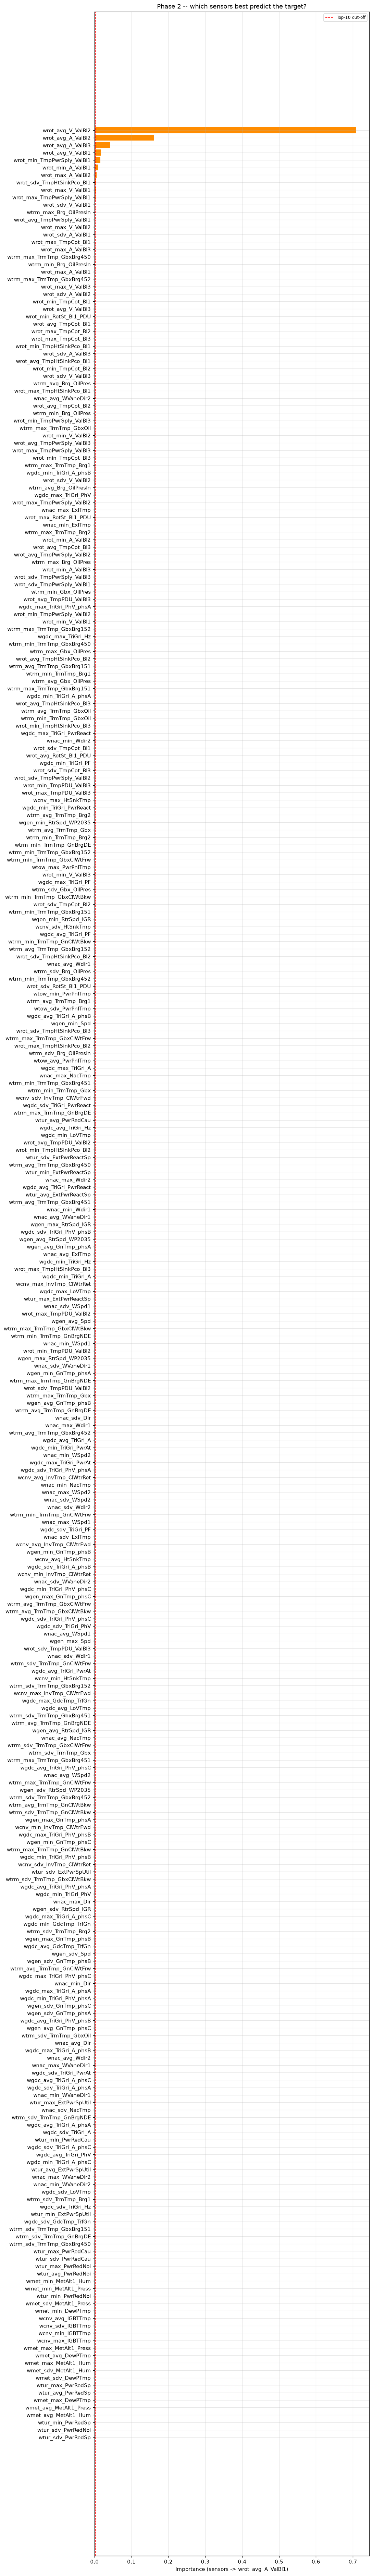

In [4]:
# Combine WT80-83, take first 50% of each as training data
train_parts = []
for tid in TRAIN_IDS:
    df_t = turbines[tid]
    half = len(df_t) // 2
    train_parts.append(df_t.iloc[:half])

# find common columns across all turbines
common_cols = set(train_parts[0].columns)
for p in train_parts[1:]:
    common_cols &= set(p.columns)
common_cols = sorted(common_cols)

train_df = pd.concat([p[common_cols] for p in train_parts], ignore_index=True)
print(f'Combined training set: {len(train_df):,} rows x {len(common_cols)} columns')
print(f'Alarm-active hours: {int(train_df["alarm_active"].sum())} / {len(train_df)}')

sensor_cols = [c for c in common_cols if c != 'alarm_active']
X_all = train_df[sensor_cols].values.astype(float)
alarm  = train_df['alarm_active'].values.astype(float)

# drop rows with any NaN in sensors
ok = ~np.isnan(X_all).any(axis=1)
X_ok, alarm_ok = X_all[ok], alarm[ok]
print(f'Rows without NaN: {ok.sum():,}')

# ---- Phase 1 ----
print('\nPhase 1: RF(all sensors -> alarm_active)...')
rf1 = RandomForestRegressor(n_estimators=RF_TREES, random_state=1, n_jobs=-1)
rf1.fit(X_ok, alarm_ok)
imp1 = pd.Series(rf1.feature_importances_, index=sensor_cols).sort_values(ascending=False)
Y_VAR = imp1.index[0]
print(f'  Y_VAR (best response): "{Y_VAR}"')
print('  Top 5 by alarm importance:')
print(imp1.head(5).round(4).to_string())

# bar chart Phase 1
fig, ax = plt.subplots(figsize=(10, max(4, len(imp1)*0.22)))
ax.barh(imp1.index[::-1], imp1.values[::-1], color='steelblue')
ax.axvline(imp1.iloc[0], color='red', linestyle='--', lw=1, label=f'winner: {Y_VAR}')
ax.set_xlabel('Importance (sensors -> gearbox alarm)')
ax.set_title('Phase 1 -- which sensor best tracks gearbox faults?')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ---- Phase 2 ----
print(f'\nPhase 2: RF(remaining sensors -> {Y_VAR})...')
input_cols = [c for c in sensor_cols if c != Y_VAR]
y_resp = train_df[Y_VAR].values[ok].astype(float)
X_input = X_ok[:, [sensor_cols.index(c) for c in input_cols]]
ok2 = ~np.isnan(y_resp)
rf2 = RandomForestRegressor(n_estimators=RF_TREES, random_state=1, n_jobs=-1)
rf2.fit(X_input[ok2], y_resp[ok2])
imp2 = pd.Series(rf2.feature_importances_, index=input_cols).sort_values(ascending=False)
X_VARS = imp2.head(MAX_VARS).index.tolist()
print(f'  Selected X_VARS (top {MAX_VARS}):')
print(imp2.head(MAX_VARS).round(4).to_string())

# bar chart Phase 2
fig, ax = plt.subplots(figsize=(10, max(4, len(imp2)*0.22)))
colors = ['darkorange' if i < MAX_VARS else 'steelblue' for i in range(len(imp2))]
ax.barh(imp2.index[::-1], imp2.values[::-1], color=colors[::-1])
ax.axvline(imp2.iloc[MAX_VARS-1], color='red', linestyle='--', lw=1,
           label=f'Top-{MAX_VARS} cut-off')
ax.set_xlabel(f'Importance (sensors -> {Y_VAR})')
ax.set_title('Phase 2 -- which sensors best predict the target?')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 4 -- ELM Class

Direct Python translation of `elm_classifier.m`:

- Random input weights `W` and biases `b` (never updated)
- Sigmoid hidden layer
- Output weights `B` solved analytically via pseudoinverse: `B = pinv(H) @ y`
- Tries multiple K values and keeps the one with lowest validation RMSE

In [5]:
class ELM:
    def __init__(self):
        self.W = self.b = self.B = None
        self.X_mu = self.X_sigma = None
        self.y_mu = self.y_sigma = None

    def _hidden(self, Xn):
        return 1.0 / (1.0 + np.exp(-(Xn @ self.W + self.b)))

    def fit(self, X, y, K_range, seed=1):
        ok = ~(np.isnan(X).any(axis=1) | np.isnan(y))
        X, y = X[ok], y[ok]
        # normalize
        self.X_mu    = X.mean(0); self.X_sigma = X.std(0); self.X_sigma[self.X_sigma==0] = 1
        self.y_mu    = y.mean();  self.y_sigma = y.std()  or 1.0
        Xn = (X - self.X_mu) / self.X_sigma
        yn = (y - self.y_mu) / self.y_sigma
        N, d = Xn.shape
        # validation split inside training: last 20%
        split = int(N * 0.8)
        Xtr, ytr = Xn[:split], yn[:split]
        Xval, yval = Xn[split:], y[split:]
        best_rmse, best_K = np.inf, K_range[0]
        best_W = best_b = best_B = None
        np.random.seed(seed)
        for K in K_range:
            W = np.random.randn(d, K)
            b = np.random.randn(K)
            H = 1.0 / (1.0 + np.exp(-(Xtr @ W + b)))
            B = np.linalg.pinv(H) @ ytr
            Hv = 1.0 / (1.0 + np.exp(-(Xval @ W + b)))
            yhat = Hv @ B * self.y_sigma + self.y_mu
            rmse = np.sqrt(np.mean((yval - yhat)**2))
            if rmse < best_rmse:
                best_rmse = rmse; best_K = K
                best_W, best_b, best_B = W.copy(), b.copy(), B.copy()
        self.W, self.b, self.B = best_W, best_b, best_B
        print(f'  Best K={best_K}  |  val RMSE={best_rmse:.4f}')
        return self

    def predict(self, X):
        Xn = (X - self.X_mu) / self.X_sigma
        return self._hidden(Xn) @ self.B * self.y_sigma + self.y_mu

    def evaluate(self, X, y, label='Test'):
        ok = ~(np.isnan(X).any(axis=1) | np.isnan(y))
        yhat = self.predict(X[ok])
        y_ok = y[ok]
        rmse  = np.sqrt(np.mean((y_ok - yhat)**2))
        nrmse = rmse / (y_ok.max() - y_ok.min()) if (y_ok.max() - y_ok.min()) > 0 else 0
        print(f'  [{label}] RMSE={rmse:.4f}  |  Norm RMSE={nrmse:.4f}  ({nrmse*100:.1f}%)')
        return rmse, nrmse

print('ELM class ready')


ELM class ready


## 5 -- Train ELM on WT80-83

Trains on the first 50% of WT80-83. Evaluates on the second 50%.
This mirrors exactly what `example_elm.m` does.

Train: 35,814 rows  |  Test: 35,816 rows

Training ELM...
  Best K=125  |  val RMSE=0.0753
  [WT80-83 test] RMSE=0.1259  |  Norm RMSE=0.0664  (6.6%)


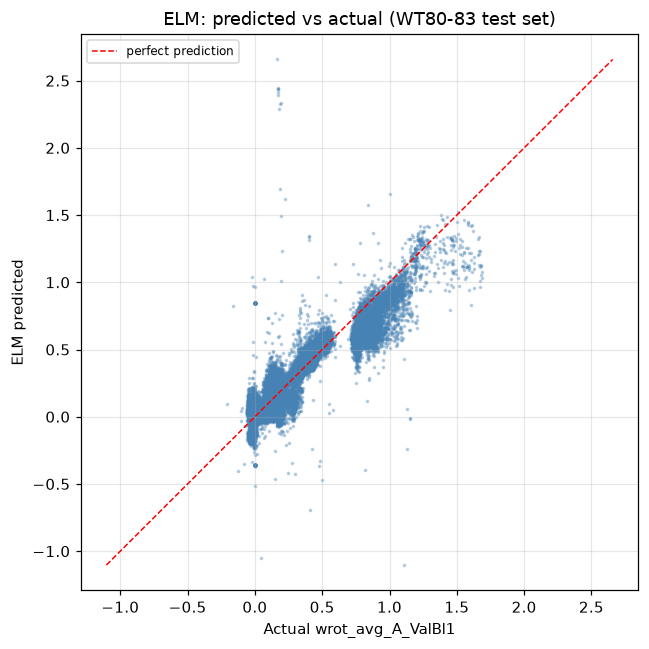

In [6]:
# build train / test sets from WT80-83
def get_split(turbine_id, x_vars, y_var, half='first'):
    df_t  = turbines[turbine_id][x_vars + [y_var]].dropna()
    n     = len(df_t)
    chunk = df_t.iloc[:n//2] if half == 'first' else df_t.iloc[n//2:]
    return chunk[x_vars].values.astype(float), chunk[y_var].values.astype(float)

X_tr_parts, y_tr_parts = [], []
X_te_parts, y_te_parts = [], []
for tid in TRAIN_IDS:
    Xtr, ytr = get_split(tid, X_VARS, Y_VAR, 'first')
    Xte, yte = get_split(tid, X_VARS, Y_VAR, 'second')
    X_tr_parts.append(Xtr); y_tr_parts.append(ytr)
    X_te_parts.append(Xte); y_te_parts.append(yte)

X_train = np.vstack(X_tr_parts); y_train = np.concatenate(y_tr_parts)
X_test  = np.vstack(X_te_parts); y_test  = np.concatenate(y_te_parts)
print(f'Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows')

print('\nTraining ELM...')
elm = ELM()
elm.fit(X_train, y_train, K_range=ELM_K_RANGE)
elm.evaluate(X_test, y_test, label='WT80-83 test')

# quick scatter: predicted vs actual on test set
ok = ~(np.isnan(X_test).any(axis=1) | np.isnan(y_test))
yhat_test = elm.predict(X_test[ok])
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test[ok], yhat_test, s=2, alpha=0.3, color='steelblue', rasterized=True)
lo, hi = min(y_test[ok].min(), yhat_test.min()), max(y_test[ok].max(), yhat_test.max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=1, label='perfect prediction')
ax.set_xlabel(f'Actual {Y_VAR[:35]}')
ax.set_ylabel('ELM predicted')
ax.set_title('ELM: predicted vs actual (WT80-83 test set)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 6 -- Apply to WT84: Anomaly Detection

Trained on WT80-83. Now feed WT84's sensor readings into the ELM.

The ELM keeps predicting 'what the bearing temperature SHOULD be given normal operation.' When the actual temperature diverges upward, that gap is the early warning signal.

**Key dates for WT84:**
- 2013: alarm activity (93 transmission events)
- 2014: massive alarm spike (594 transmission events) -- the failure cluster
- Data ends: 2014-12-08

In [7]:
wt84 = turbines[TEST_ID].copy()

# predict on all of WT84 where X_VARS are available
X_wt84 = wt84[X_VARS].values.astype(float)
y_wt84 = wt84[Y_VAR].values.astype(float)
ts_wt84 = wt84.index

ok84 = ~(np.isnan(X_wt84).any(axis=1) | np.isnan(y_wt84))
y_pred_84 = np.full(len(wt84), np.nan)
y_pred_84[ok84] = elm.predict(X_wt84[ok84])

residual = y_wt84 - y_pred_84   # positive = actual higher than expected

# rolling window anomaly score (smoothed residual)
res_series = pd.Series(residual, index=ts_wt84)
anomaly_score = res_series.rolling(ANOMALY_WINDOW, min_periods=1, center=True).mean()

# alarm periods for shading
alarm_series = wt84['alarm_active']
alarm_starts, alarm_ends = [], []
in_alarm = False
for t, v in alarm_series.items():
    if v == 1 and not in_alarm:
        alarm_starts.append(t); in_alarm = True
    elif v == 0 and in_alarm:
        alarm_ends.append(t); in_alarm = False
if in_alarm: alarm_ends.append(alarm_series.index[-1])

rmse84, nrmse84 = elm.evaluate(X_wt84[ok84], y_wt84[ok84], label='WT84 full timeline')
print(f'Residual stats: mean={residual[ok84].mean():.3f}  std={residual[ok84].std():.3f}')
print(f'WT84 alarm hours: {int(alarm_series.sum())} / {len(alarm_series)}')


  [WT84 full timeline] RMSE=1.0216  |  Norm RMSE=0.0607  (6.1%)
Residual stats: mean=-0.140  std=1.012
WT84 alarm hours: 7844 / 25734


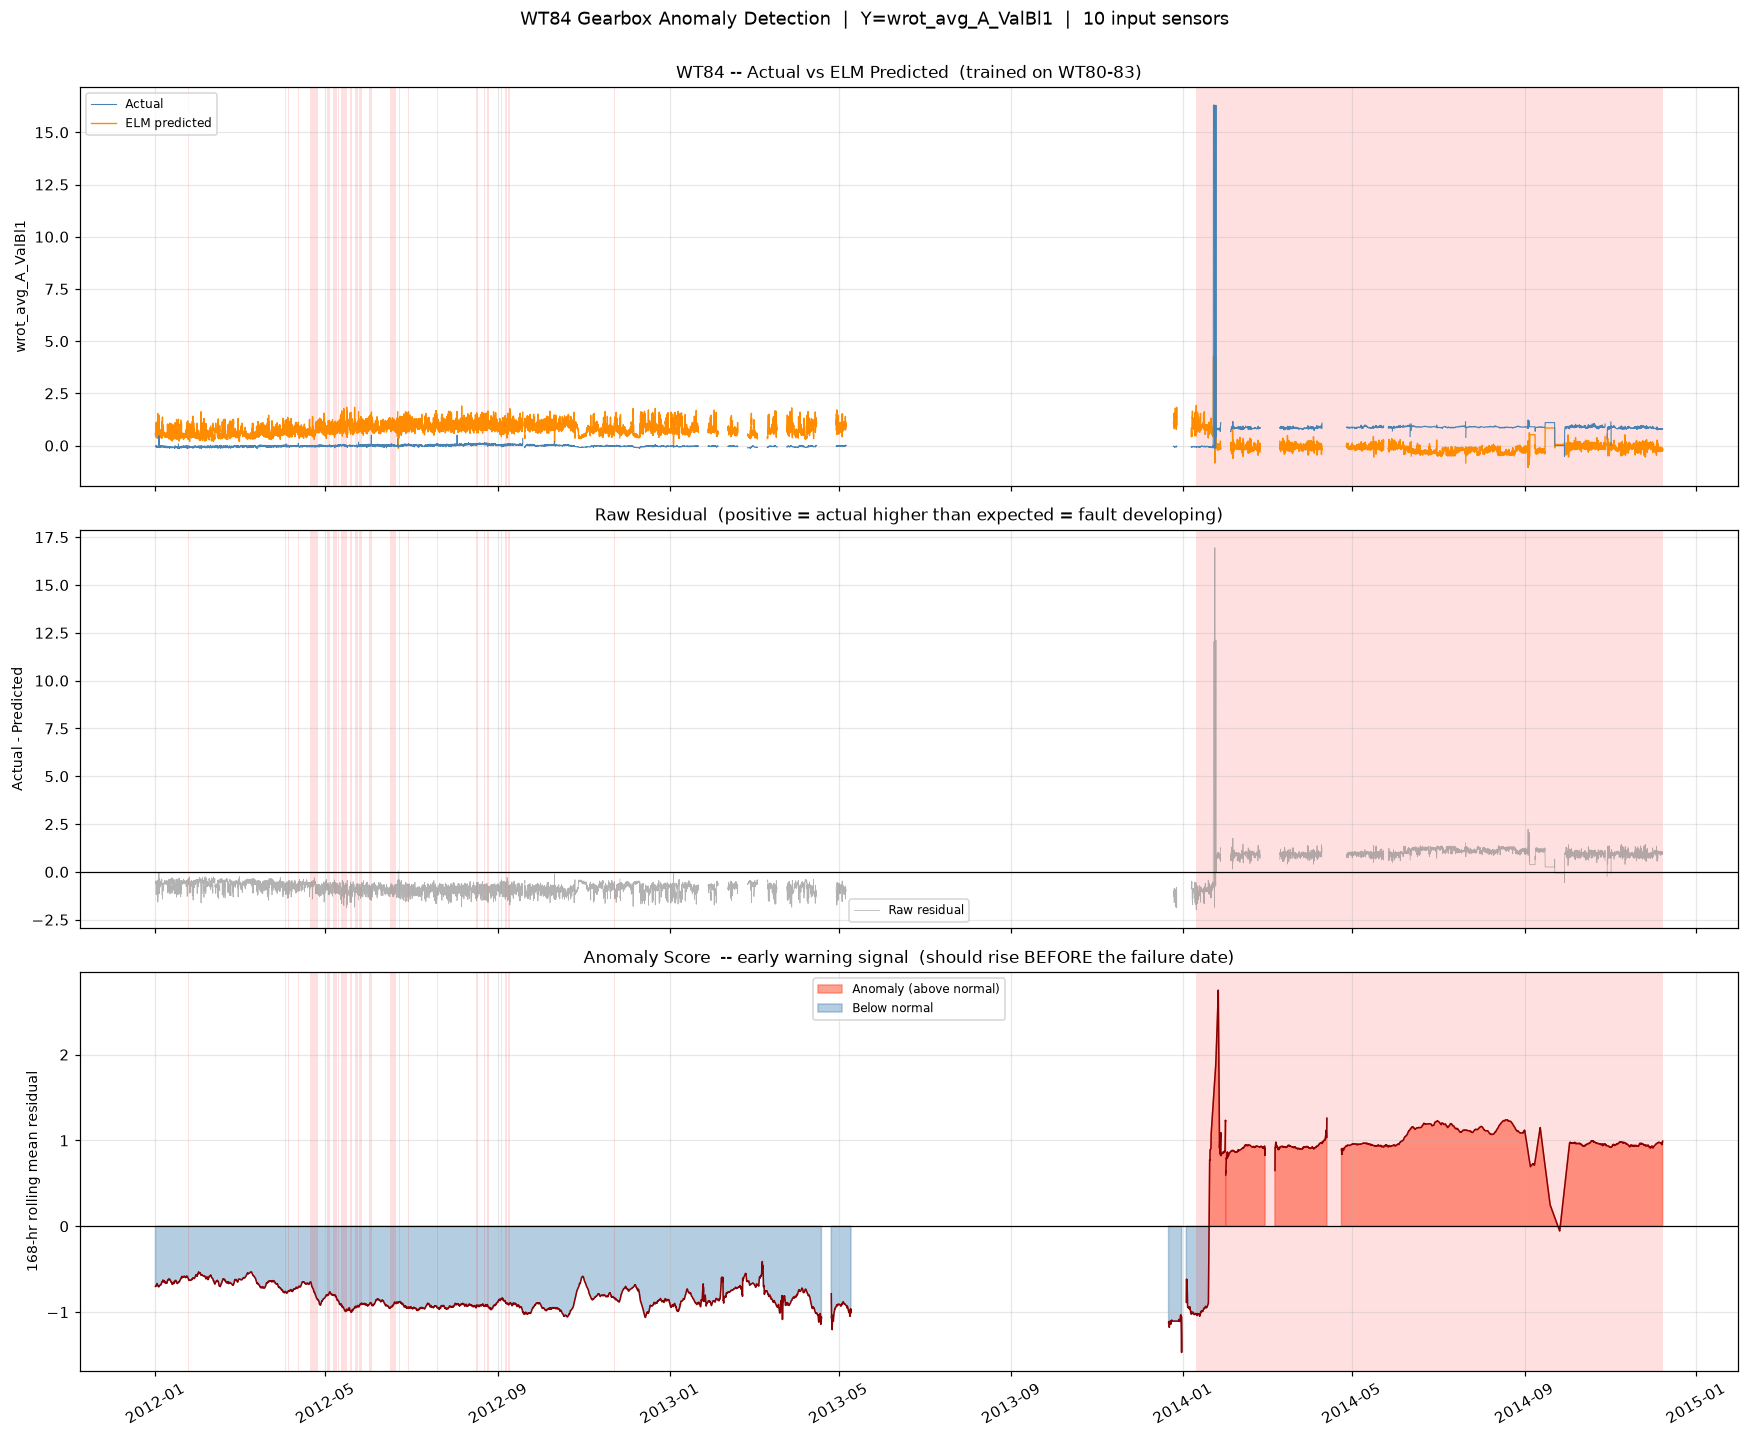

Saved: wt84_anomaly.png


In [8]:
fig, axs = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
failure = pd.Timestamp(FAILURE_DATE) if FAILURE_DATE else None

# ---- Panel 1: Actual vs Predicted bearing temp ----------------------------
ax = axs[0]
ax.plot(ts_wt84, y_wt84,    lw=0.7, color='steelblue',  label='Actual',    zorder=3)
ax.plot(ts_wt84, y_pred_84, lw=0.9, color='darkorange', label='ELM predicted', zorder=2)
for s, e in zip(alarm_starts, alarm_ends):
    ax.axvspan(s, e, color='red', alpha=0.12, linewidth=0)
if failure: ax.axvline(failure, color='red', lw=1.5, linestyle='--', label=f'Failure marker ({FAILURE_DATE})')
ax.set_ylabel(f'{Y_VAR[:35]}', fontsize=9)
ax.set_title(f'WT84 -- Actual vs ELM Predicted  (trained on WT80-83)', fontsize=11)
ax.legend(fontsize=8, loc='upper left')

# ---- Panel 2: Raw residual ------------------------------------------------
ax = axs[1]
ax.plot(ts_wt84, residual, lw=0.5, color='grey', alpha=0.6, label='Raw residual')
ax.axhline(0, color='black', lw=0.8)
for s, e in zip(alarm_starts, alarm_ends):
    ax.axvspan(s, e, color='red', alpha=0.12, linewidth=0)
if failure: ax.axvline(failure, color='red', lw=1.5, linestyle='--')
ax.set_ylabel('Actual - Predicted', fontsize=9)
ax.set_title('Raw Residual  (positive = actual higher than expected = fault developing)', fontsize=11)
ax.legend(fontsize=8)

# ---- Panel 3: Rolling anomaly score ---------------------------------------
ax = axs[2]
ax.fill_between(ts_wt84, 0, anomaly_score,
                where=anomaly_score > 0, color='tomato',  alpha=0.6, label='Anomaly (above normal)')
ax.fill_between(ts_wt84, 0, anomaly_score,
                where=anomaly_score <= 0, color='steelblue', alpha=0.4, label='Below normal')
ax.plot(ts_wt84, anomaly_score, lw=1.0, color='darkred')
ax.axhline(0, color='black', lw=0.8)
for s, e in zip(alarm_starts, alarm_ends):
    ax.axvspan(s, e, color='red', alpha=0.12, linewidth=0)
if failure: ax.axvline(failure, color='red', lw=1.5, linestyle='--', label=f'Failure marker ({FAILURE_DATE})')
ax.set_ylabel(f'{ANOMALY_WINDOW}-hr rolling mean residual', fontsize=9)
ax.set_title('Anomaly Score  -- early warning signal  (should rise BEFORE the failure date)', fontsize=11)
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)

fig.suptitle(f'WT84 Gearbox Anomaly Detection  |  Y={Y_VAR[:40]}  |  {MAX_VARS} input sensors',
             fontsize=12, y=1.002)
plt.tight_layout()
plt.savefig('wt84_anomaly.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: wt84_anomaly.png')

## 7 -- Save selected features (raw 5-min)

Re-reads the RAW 5-min data and saves one CSV per turbine containing **only** the selected columns (`[Y_VAR] + X_VARS`). Feature finding above used hourly data; the saved data is 5-min so downstream causal / window work keeps full resolution. Values are raw -- we only place them on a regular 5-min grid so missing intervals become NaN rows.

In [9]:
def read_raw_5min(turbine_id, dataset_path):
    """Load one turbine's RAW 5-min analog data (all sensor cols)."""
    plant = json.loads(open(f'{dataset_path}/wind_plant_data.json').read())
    turbs = plant['turbines']
    idx   = turbs['turbine_id'].index(turbine_id)
    fname = turbs['compressed_filename'][idx]
    with open(f'{dataset_path}/{fname}', 'rb') as f:
        raw = json.loads(bz2.decompress(f.read()).decode('utf-8'))
    ad = raw['analog_data']
    ts = pd.to_datetime(ad['date_time'])
    sensors = {k: v for k, v in ad.items() if k not in ('turbine_id', 'date_time')}
    df = pd.DataFrame(sensors, index=ts).sort_index()
    df.index.name = 'timestamp'
    return df


keep_cols = [Y_VAR] + X_VARS
all_ids   = TRAIN_IDS + [TEST_ID]
print('Saving raw ' + SAVE_FREQ + ' feature CSVs (' + str(len(keep_cols)) + ' cols)')
print('Columns: ' + str(keep_cols) + '\n')

for tid in all_ids:
    raw_df  = read_raw_5min(tid, DATASET_PATH)
    avail   = [c for c in keep_cols if c in raw_df.columns]
    missing = [c for c in keep_cols if c not in raw_df.columns]
    if missing:
        print('  [WARN] WT' + str(tid) + ' missing ' + str(missing))
    # narrow first (memory), coerce numeric, then regularize onto a 5-min grid
    sub  = raw_df[avail].apply(pd.to_numeric, errors='coerce')
    grid = sub.resample(SAVE_FREQ).mean()
    grid.index.name = 'timestamp'
    path = os.path.join(OUTPUT_DIR, 'wt' + str(tid) + '_features.csv')
    grid.to_csv(path)
    n_blank = int(grid.isna().all(axis=1).sum())
    print('  WT' + str(tid) + ': ' + str(len(grid)) + ' rows x ' + str(grid.shape[1])
          + ' cols (blank rows: ' + str(n_blank) + ') -> ' + path)
    del raw_df, sub, grid

print('\nDone. Raw ' + SAVE_FREQ + ' feature files in: ' + OUTPUT_DIR)

Saving raw 5min feature CSVs (11 cols)
Columns: ['wrot_avg_A_ValBl1', 'wrot_avg_V_ValBl2', 'wrot_avg_A_ValBl2', 'wrot_avg_A_ValBl3', 'wrot_avg_V_ValBl1', 'wrot_min_TmpPwrSply_ValBl1', 'wrot_min_A_ValBl1', 'wrot_max_A_ValBl2', 'wrot_sdv_TmpHtSinkPco_Bl1', 'wrot_max_V_ValBl1', 'wrot_max_TmpPwrSply_ValBl1']

  WT80: 308799 rows x 11 cols (blank rows: 93363) -> C:\Eminds pros\E-minds projects\fuhrlander\FUHRLANDER GITHUB REPO\output\wt80_features.csv
  WT81: 308798 rows x 11 cols (blank rows: 93209) -> C:\Eminds pros\E-minds projects\fuhrlander\FUHRLANDER GITHUB REPO\output\wt81_features.csv
  WT82: 308799 rows x 11 cols (blank rows: 95540) -> C:\Eminds pros\E-minds projects\fuhrlander\FUHRLANDER GITHUB REPO\output\wt82_features.csv
  WT83: 308800 rows x 11 cols (blank rows: 95352) -> C:\Eminds pros\E-minds projects\fuhrlander\FUHRLANDER GITHUB REPO\output\wt83_features.csv
  WT84: 308800 rows x 11 cols (blank rows: 98126) -> C:\Eminds pros\E-minds projects\fuhrlander\FUHRLANDER GITHUB REP